In [1]:
!pip install pandas nltk scikit-learn


In [2]:
import pandas as pd
import numpy as np
import nltk
import re
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


In [3]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kalya\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [4]:
data = {
    'text': [
        "I love this product",
        "This is the worst service ever",
        "Amazing experience",
        "Very bad quality",
        "I am extremely happy",
        "Totally disappointed",
        "Best purchase I made",
        "Not worth the money",
        "Absolutely fantastic",
        "Terrible customer support"
    ],
    
    'sentiment': [
        'positive',
        'negative',
        'positive',
        'negative',
        'positive',
        'negative',
        'positive',
        'negative',
        'positive',
        'negative'
    ]
}

df = pd.DataFrame(data)
df.head()


,text,sentiment
0,I love this product,positive
1,This is the worst service ever,negative
2,Amazing experience,positive
3,Very bad quality,negative
4,I am extremely happy,positive


In [5]:
def preprocess(text):
    
    text = text.lower()
    
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    words = text.split()
    
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

df['clean_text'] = df['text'].apply(preprocess)

df.head()


,text,sentiment,clean_text
0,I love this product,positive,love product
1,This is the worst service ever,negative,worst service ever
2,Amazing experience,positive,amazing experience
3,Very bad quality,negative,bad quality
4,I am extremely happy,positive,extremely happy


In [6]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['clean_text'])

y = df['sentiment']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [8]:
model = LogisticRegression()

model.fit(X_train, y_train)


LogisticRegression()

In [9]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.5

Classification Report:

              precision    recall  f1-score   support

    negative       0.50      1.00      0.67         1
    positive       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



C:\Users\kalya\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [10]:
sample = ["The product is really good and I like it"]

sample_clean = [preprocess(text) for text in sample]

sample_vec = vectorizer.transform(sample_clean)

prediction = model.predict(sample_vec)

print("Sentiment:", prediction[0])


Sentiment: positive


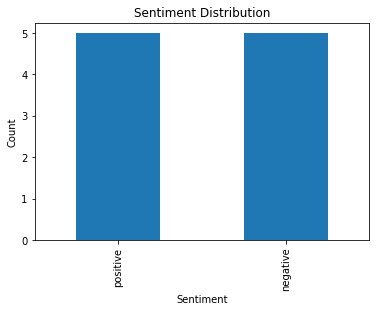

In [11]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()
